Task 1 — World Choropleth (Life Expectancy Deviation)

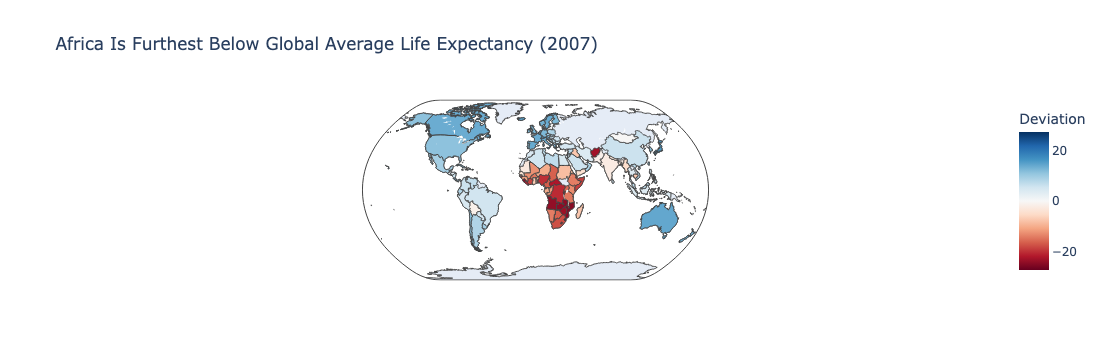

In [13]:
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
import json

# Load Gapminder dataset
gm = px.data.gapminder()

# Filter for year 2007
gm_2007 = gm[gm['year'] == 2007].copy()

# Compute global average life expectancy
global_avg = gm_2007['lifeExp'].mean()

# Compute deviation from global average
gm_2007['lifeExp_deviation'] = gm_2007['lifeExp'] - global_avg

# Find region furthest below average
lowest_region = (
    gm_2007.groupby('continent')['lifeExp_deviation']
    .mean()
    .idxmin()
)

# Create choropleth map
fig = px.choropleth(
    gm_2007,
    locations='iso_alpha',
    color='lifeExp_deviation',

    hover_name='country',

    hover_data={
        'lifeExp': ':.2f',
        'lifeExp_deviation': ':.2f',
        'iso_alpha': False
    },

    color_continuous_scale='RdBu',

    color_continuous_midpoint=0,

    projection='natural earth',

    title=f'{lowest_region} Is Furthest Below Global Average Life Expectancy (2007)'
)

fig.update_layout(
    coloraxis_colorbar_title='Deviation'
)

fig.show()


In [ ]:
# Task 2 — Germany States Choropleth

{'id': 'DE-BW', 'name': 'Baden-Württemberg', 'type': 'State'}


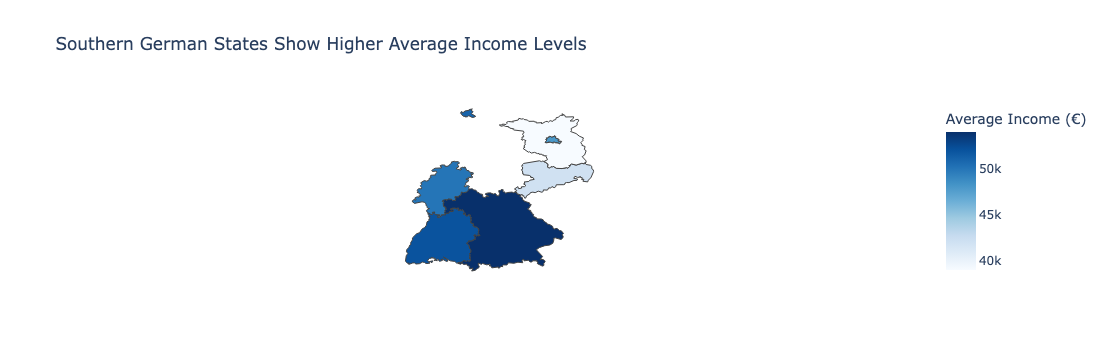

In [12]:
# Task 2 — Germany States Choropleth

import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
import json

# =========================
# Load GeoJSON
# =========================

with open('/Users/sahilsantoshdangat/Downloads/4_niedrig.geo.json', 'r') as file:
    germany_geojson = json.load(file)

# Inspect GeoJSON properties
print(germany_geojson['features'][0]['properties'])

# =========================
# Create Matching Dataset
# =========================

df = pd.DataFrame({
    'state': [
        'Baden-Württemberg',
        'Bayern',
        'Berlin',
        'Hamburg',
        'Hessen',
        'Sachsen',
        'Brandenburg'
    ],

    'average_income': [
        52000,
        54000,
        48000,
        51000,
        50000,
        42000,
        39000
    ]
})

# =========================
# Create Choropleth
# =========================

fig = px.choropleth(
    df,

    geojson=germany_geojson,

    locations='state',

    featureidkey='properties.name',

    color='average_income',

    color_continuous_scale='Blues',

    hover_name='state',

    hover_data={
        'average_income': True
    },

    title='Southern German States Show Higher Average Income Levels'
)

fig.update_geos(
    fitbounds="locations",
    visible=False
)

fig.update_layout(
    coloraxis_colorbar_title='Average Income (€)'
)

fig.show()